# Fine-Tuning et Transfer Learning en Computer Vision avec Keras et TensorFlow
## Classification d'Images satellites avec différents modèles pré-entrainés

## Objectifs de ce notebook

Dans ce notebook, nous allons explorer le **fine-tuning** et le **transfer learning** pour la classification d'images en computer vision avec **Keras** et **TensorFlow** :

1. **Comprendre le Transfer Learning** - Réutiliser des connaissances pré-apprises
2. **Utiliser des modèles pré-entraînés** - MobileNetV3, ... entraîné sur ImageNet
3. **Charger MobileNetV3 avec Keras** - Modèle pré-entraîné prêt à l'emploi
4. **Fine-tuning sur Eurosat** - Adapter le modèle à la classification d'images satellites
5. **Classification et prédiction** - Identifier 10 classes dans les images satellites

Nous utiliserons le célèbre dataset **Eurosat** (3000 images de 10 classes) pour fine-tuner  et classifier.

## 🎯 Configuration Optimale Testée

Ce notebook utilise une **configuration éprouvée** qui fonctionne bien sur le dataset Eurosat :

### Architecture du Classifier

```python
Input(224,224,3)
    ↓
Modèle pré-entrainé (frozen) → 1280 features
    ↓
Dropout(0.3)
    ↓
Dense(256, relu, L2=0.01)  # Couche cachée
    ↓
Dropout(0.3)
    ↓
Dense(5, softmax)  # Classification
```

**Pourquoi cette architecture ?**
- **Dense(256)** : Capacité suffisante sans overfitting
- **Dropout(0.3)** : Régularisation modérée
- **L2(0.01)** : Prévient les poids trop grands
- **Pas de Batch Normalization** : Évite les conflits avec le freeze/unfreeze

### Hyperparamètres Optimaux

**Feature Extraction (Frozen)** :
- Learning rate : **0.001** (standard Adam)
- Batch size : **32**
- Epochs : **30** (avec early stopping)
- Patience : **10** epochs
- Dropout : **0.3**
- L2 regularization : **0.01**

**Fine-Tuning (Unfrozen)** :
- Learning rate : **1e-5** (100x plus faible)
- Epochs : **30-50**
- Patience : **15** epochs
- Unfreezing : **Dernières 55 couches** (sur 155)
- **Approche directe** : Dégel du modèle frozen en place

### Stratégie de Fine-Tuning Simplifiée

```python
# ✅ Approche qui FONCTIONNE
# 1. Entraîner le classifier avec base_model frozen
model_frozen.fit(...)  # Atteint ~70-85%

# 2. Dégeler le base_model en place
base_model.trainable = True

# 3. Geler seulement les premières couches
for i in range(100):
    base_model.layers[i].trainable = False

# 4. Recompiler avec LR très faible
model_frozen.compile(optimizer=Adam(lr=1e-5), ...)

# 5. Continuer l'entraînement
model_finetuned = model_frozen  # Même objet!
model_finetuned.fit(...)  # Améliore à ~80-90%
```

**Performances attendues** :
- Feature Extraction : **70-85% accuracy**
- Fine-Tuning : **80-92% accuracy**
- Top-2 Accuracy : **90-98%**

## Pourquoi Keras et TensorFlow ?

**TensorFlow** (2.x+) apporte :
- **Production-ready** : Déploiement facile
- **Performance optimisée** : GPU et TPU natifs
- **Écosystème riche** : TensorFlow Hub, TF Lite, TF Serving

**Keras** offre :
- **API intuitive** : Simple et pythonique
- **Modèles pré-entraînés** : VGG, ResNet, MobileNet, EfficientNet
- **Applications intégrées** : `keras.applications`
- **Fine-tuning facile** : Freeze/unfreeze en une ligne

## 📚 Concepts clés que nous allons explorer

- **Modèles pré-entraînés** : MobileNetV2 sur ImageNet
- **Feature Extraction** : Utiliser les représentations apprises (frozen)
- **Fine-Tuning** : Adapter les poids du modèle (unfrozen)
- **Regularization** : Dropout + L2 pour prévenir l'overfitting
- **Data Augmentation** : Augmenter artificiellement le dataset
- **Callbacks** : Early stopping, learning rate scheduling
- **Approche directe** : Fine-tuning sans re-création de modèle

## 🎯 Architecture du notebook

```
Installation → MobileNetV3 → Exploration Eurosat → Baseline (frozen) → Fine-tuning → Comparaison → Prédiction
```

## 1. Installation et Configuration

In [2]:
# Installation des dépendances (décommentez si nécessaire)
# !pip install -q tensorflow>=2.16.0
# !pip install -q keras>=3.0.0
# !pip install -q pillow
# !pip install -q matplotlib seaborn
%pip install -U kagglehub
print("✅ Installation terminée !")

Note: you may need to restart the kernel to use updated packages.
✅ Installation terminée !


In [3]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, Image as IPImage, display
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
#print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le fine-tuning en computer vision !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.15.1
  - NumPy      : 1.26.4

🚀 Prêt pour le fine-tuning en computer vision !


## 2. Comprendre le Transfer Learning

### 2.1 Qu'est-ce que le Transfer Learning ?

Le transfer learning consiste à **transférer** les connaissances d'un modèle pré-entraîné vers une nouvelle tâche.

#### Analogie : Apprendre à reconnaître des objets

Imaginez que vous savez déjà reconnaître des animaux :
- **Pré-entraînement** : Vous avez appris à identifier des formes, textures, couleurs
- **Transfer Learning** : Identifier des races de chiens est plus facile car vous connaissez déjà les concepts visuels
- **Fine-Tuning** : Adapter vos connaissances visuelles aux races de chiens spécifiquement

### 2.2 Les deux approches principales

#### 🧊 Feature Extraction (Frozen)
```
Modèle pré-entraîné → [FREEZE] → Ajouter couches de classification → Entraîner seulement les nouvelles couches
```
- **Avantages** : Rapide, peu de données nécessaires, pas de catastrophic forgetting
- **Inconvénients** : Performances limitées si la tâche est très différente

#### 🔥 Fine-Tuning (Unfrozen)
```
Modèle pré-entraîné → [UNFREEZE] → Ajuster tous les poids → Learning rate faible
```
- **Avantages** : Meilleures performances, adaptation complète à la tâche
- **Inconvénients** : Plus lent, risque d'overfitting, nécessite plus de données

### 2.3 Visualisation du Transfer Learning

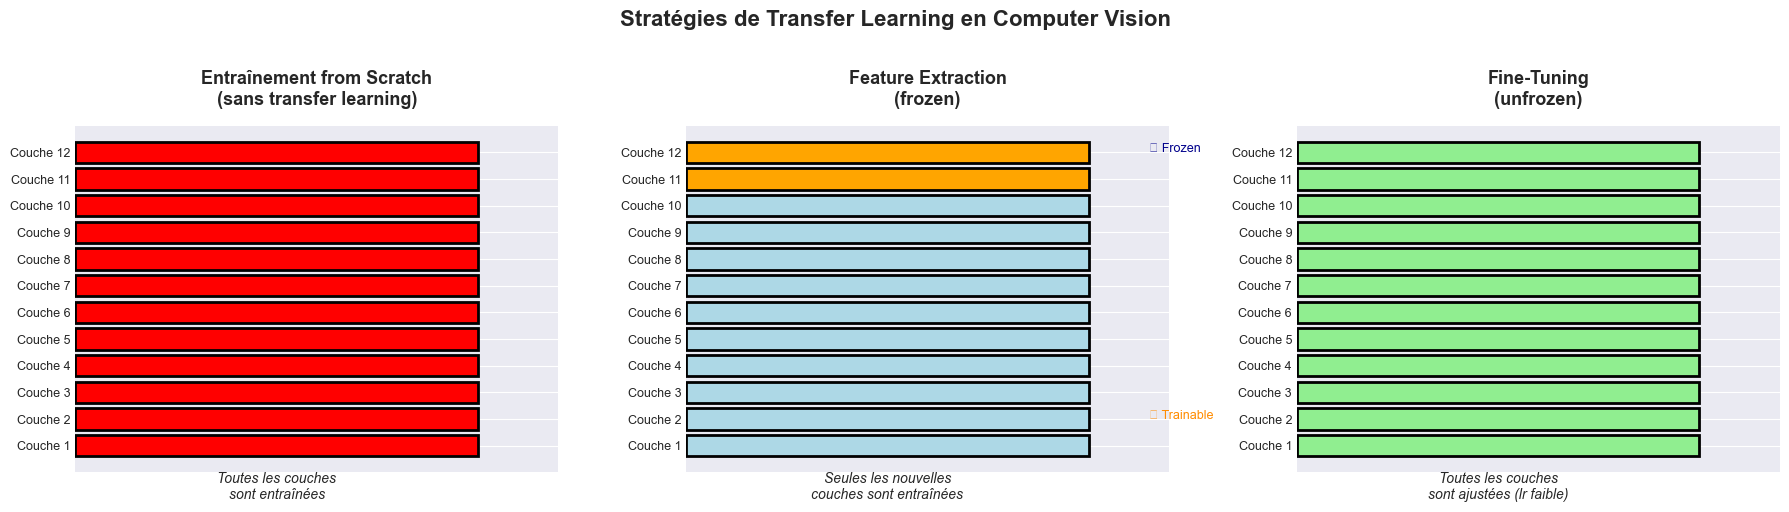


💡 Dans ce notebook, nous allons explorer les deux approches avec Keras !


In [4]:
# Visualisation des stratégies de transfer learning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies = [
    ("Entraînement from Scratch\n(sans transfer learning)", 
     ['red']*12, "Toutes les couches\nsont entraînées"),
    ("Feature Extraction\n(frozen)", 
     ['lightblue']*10 + ['orange']*2, "Seules les nouvelles\ncouches sont entraînées"),
    ("Fine-Tuning\n(unfrozen)", 
     ['lightgreen']*12, "Toutes les couches\nsont ajustées (lr faible)")
]

for idx, (title, colors, desc) in enumerate(strategies):
    ax = axes[idx]
    
    # Dessiner les couches
    for i, color in enumerate(colors):
        ax.barh(i, 1, color=color, edgecolor='black', linewidth=2)
    
    ax.set_ylim(-1, 12)
    ax.set_xlim(0, 1.2)
    ax.set_yticks(range(12))
    ax.set_yticklabels([f'Couche {i+1}' for i in range(12)], fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.text(0.5, -2, desc, ha='center', fontsize=10, style='italic')
    
    # Légende
    if idx == 1:
        ax.text(1.15, 11, '🔒 Frozen', fontsize=9, color='darkblue')
        ax.text(1.15, 1, '🔓 Trainable', fontsize=9, color='darkorange')

plt.suptitle('Stratégies de Transfer Learning en Computer Vision', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Dans ce notebook, nous allons explorer les deux approches avec Keras !")

## 3. Chargement du Modèle Pré-entraîné avec Keras : MobileNetV2

### 3.1 Pourquoi MobileNetV2 ?

**MobileNetV2** (Google, 2018) :
- **3.5M paramètres** - Léger et rapide
- Pré-entraîné sur **ImageNet** (1.4M images, 1000 classes)
- Architecture **efficiente** optimisée pour mobile
- **Inverted residuals** et **linear bottlenecks**
- Précision de **71.8% Top-1** sur ImageNet

**Avantages** :
- Rapide à entraîner
- Faible consommation mémoire
- Excellent pour le fine-tuning
- Déployable sur appareils mobiles

### 3.2 Architecture MobileNetV2

```
Input (224x224x3) → [Conv Block] → [Inverted Residual Blocks × 17] → [Conv 1x1] → [Global Average Pooling] → [Dense 1000]
```

Chaque bloc contient :
- **Expansion** : Augmenter les canaux (expansion factor 6)
- **Depthwise Convolution** : Convolutions séparées par canal
- **Projection** : Réduction linéaire des canaux
- **Skip connections** : Connexions résiduelles

In [5]:
print("📥 Chargement du modèle MobileNetV2 avec Keras...")
print("   (Cela peut prendre quelques secondes la première fois)\n")

# Charger MobileNetV2 pré-entraîné sans le classifier (include_top=False)
# On va ajouter notre propre classifier pour les fleurs
base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,  # Exclure la couche de classification ImageNet
    weights='imagenet',  # Charger les poids pré-entraînés sur ImageNet
    pooling='avg'  # Global Average Pooling à la fin
)

print("✅ Modèle MobileNetV3 chargé !\n")

# Afficher la structure du modèle
print("📋 Structure du modèle MobileNetV3 :")
print(f"  - Architecture   : MobileNetV3")
print(f"  - Input shape    : (224, 224, 3)")
print(f"  - Poids          : ImageNet (1000 classes)")
print(f"  - Output shape   : {base_model.output_shape}")
print(f"  - Nombre de couches : {len(base_model.layers)}")

# Compter les paramètres
total_params = base_model.count_params()
print(f"\n  - Nombre total de paramètres : {total_params:,}")
print(f"  - Taille en mémoire (approx.) : {total_params * 4 / (1024**2):.1f} MB")

print("\n💡 Ce modèle a déjà été entraîné sur 1.4 million d'images !")
print("   Nous allons maintenant l'adapter à notre tâche de classification de fleurs.")

📥 Chargement du modèle MobileNetV2 avec Keras...
   (Cela peut prendre quelques secondes la première fois)



2026-06-01 15:59:32.186766: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-01 15:59:32.186789: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-01 15:59:32.186793: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-06-01 15:59:32.186815: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-01 15:59:32.186826: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Modèle MobileNetV3 chargé !

📋 Structure du modèle MobileNetV3 :
  - Architecture   : MobileNetV3
  - Input shape    : (224, 224, 3)
  - Poids          : ImageNet (1000 classes)
  - Output shape   : (None, 576)
  - Nombre de couches : 230

  - Nombre total de paramètres : 939,120
  - Taille en mémoire (approx.) : 3.6 MB

💡 Ce modèle a déjà été entraîné sur 1.4 million d'images !
   Nous allons maintenant l'adapter à notre tâche de classification de fleurs.


### 3.3 Visualisation de l'architecture MobileNetV2

In [6]:
print("🔍 Aperçu des couches de MobileNetV2\n")
print("="*80)

# Fonction helper pour obtenir l'output shape
def get_output_shape(layer):
    try:
        if hasattr(layer, 'output_shape'):
            return str(layer.output_shape)
        elif hasattr(layer, 'output'):
            return str(layer.output.shape)
        else:
            return "N/A"
    except:
        return "N/A"

# Afficher les 10 premières et 10 dernières couches
print("\n📌 Premières couches (extraction de features bas niveau) :")
for i, layer in enumerate(base_model.layers[:10]):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n      ...")

print("\n📌 Dernières couches (features haut niveau) :")
for i, layer in enumerate(base_model.layers[-10:], start=len(base_model.layers)-10):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n" + "="*80)

🔍 Aperçu des couches de MobileNetV2


📌 Premières couches (extraction de features bas niveau) :
    1. input_1                                  | Output: [(None, 224, 224, 3)]          | Trainable: True
    2. rescaling                                | Output: (None, 224, 224, 3)            | Trainable: True
    3. Conv                                     | Output: (None, 112, 112, 16)           | Trainable: True
    4. Conv/BatchNorm                           | Output: (None, 112, 112, 16)           | Trainable: True
    5. tf.__operators__.add                     | Output: (None, 112, 112, 16)           | Trainable: True
    6. re_lu                                    | Output: (None, 112, 112, 16)           | Trainable: True
    7. tf.math.multiply                         | Output: (None, 112, 112, 16)           | Trainable: True
    8. multiply                                 | Output: (None, 112, 112, 16)           | Trainable: True
    9. expanded_conv/depthwise/pad              

## 4. Chargement et Exploration du Dataset Eurosat

### 4.1 Le Dataset Eurosat

**TensorFlow Eurosat Dataset** :
- **300 000 images** de paysages
- **10 classes** : Zone agricole, Foret, Vegetation, Autoroute, Zone industrielle, Prairie/Paturage, Culture permanente, Zone résidentielle, Rivière, Mer ou lac
- Images de tailles variées (~64x64 en moyenne)
- Dataset équilibré (~3000 images par classe)

**Notre utilisation** : Classification multi-classe  avec fine-tuning.

In [7]:
print("📦 Chargement d'EurosatT...")
import kagglehub

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
data_dir = os.path.join(path, "EuroSAT")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# =========================
# SPLIT VAL / TEST
# =========================

temp_ds = temp_ds.shuffle(1000, seed=42)

# Nombre de batchs
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

# 50% VAL / 50% TEST
val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

print("Train batches :", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches   :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches  :", tf.data.experimental.cardinality(test_ds).numpy())

# Classes
class_names = train_ds.class_names
print(f"\n🏷️ 10 classes : {', '.join(class_names)}")

📦 Chargement d'EurosatT...
Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Train batches : 675
Val batches   : 84
Test batches  : 85

🏷️ 10 classes : AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake


In [8]:








print("📥 Téléchargement du dataset Eurosat...\n")


data_dir = Path(data_dir)

print("✅ Dataset téléchargé !\n")

# Explorer la structure et filtrer les vraies classes (exclure LICENSE.txt, etc.)
print("📂 Structure du dataset :")
all_items = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"  - Tous les dossiers trouvés : {all_items}")

# Filtrer pour ne garder que les vraies classes de fleurs
# Exclure tout ce qui n'est pas une classe de fleur

class_names = train_ds.class_names
class_names = sorted(class_names)

print(f"  - Classes valides : {class_names}")
print(f"  - Nombre de classes : {len(class_names)}")

if len(class_names) != 5:
    print("\n⚠️  Attention : Nombre de classes incorrect !")
    print("   Vérification du contenu du dataset...")

# Compter les images par classe
print("\n📊 Distribution des images par classe :")
class_counts = {}
total_images = 0
for class_name in class_names:
    class_path = data_dir / class_name
    count = len(list(class_path.glob('*.jpg')))
    class_counts[class_name] = count
    total_images += count
    print(f"  - {class_name:15s} : {count:4d} images")

print(f"\n  - Total : {total_images} images")
print(f"  - Moyenne par classe : {total_images / len(class_names):.0f} images")

📥 Téléchargement du dataset Eurosat...

✅ Dataset téléchargé !

📂 Structure du dataset :
  - Tous les dossiers trouvés : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  - Classes valides : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  - Nombre de classes : 10

⚠️  Attention : Nombre de classes incorrect !
   Vérification du contenu du dataset...

📊 Distribution des images par classe :
  - AnnualCrop      : 3000 images
  - Forest          : 3000 images
  - HerbaceousVegetation : 3000 images
  - Highway         : 2500 images
  - Industrial      : 2500 images
  - Pasture         : 2000 images
  - PermanentCrop   : 2500 images
  - Residential     : 3000 images
  - River           : 2500 images
  - SeaLake         : 3000 images

  - Total : 27000 images
  - Moyenne par classe : 2700 images


### 4.2 Visualisation d'exemples d'images

🌸 Exemples d'images du dataset



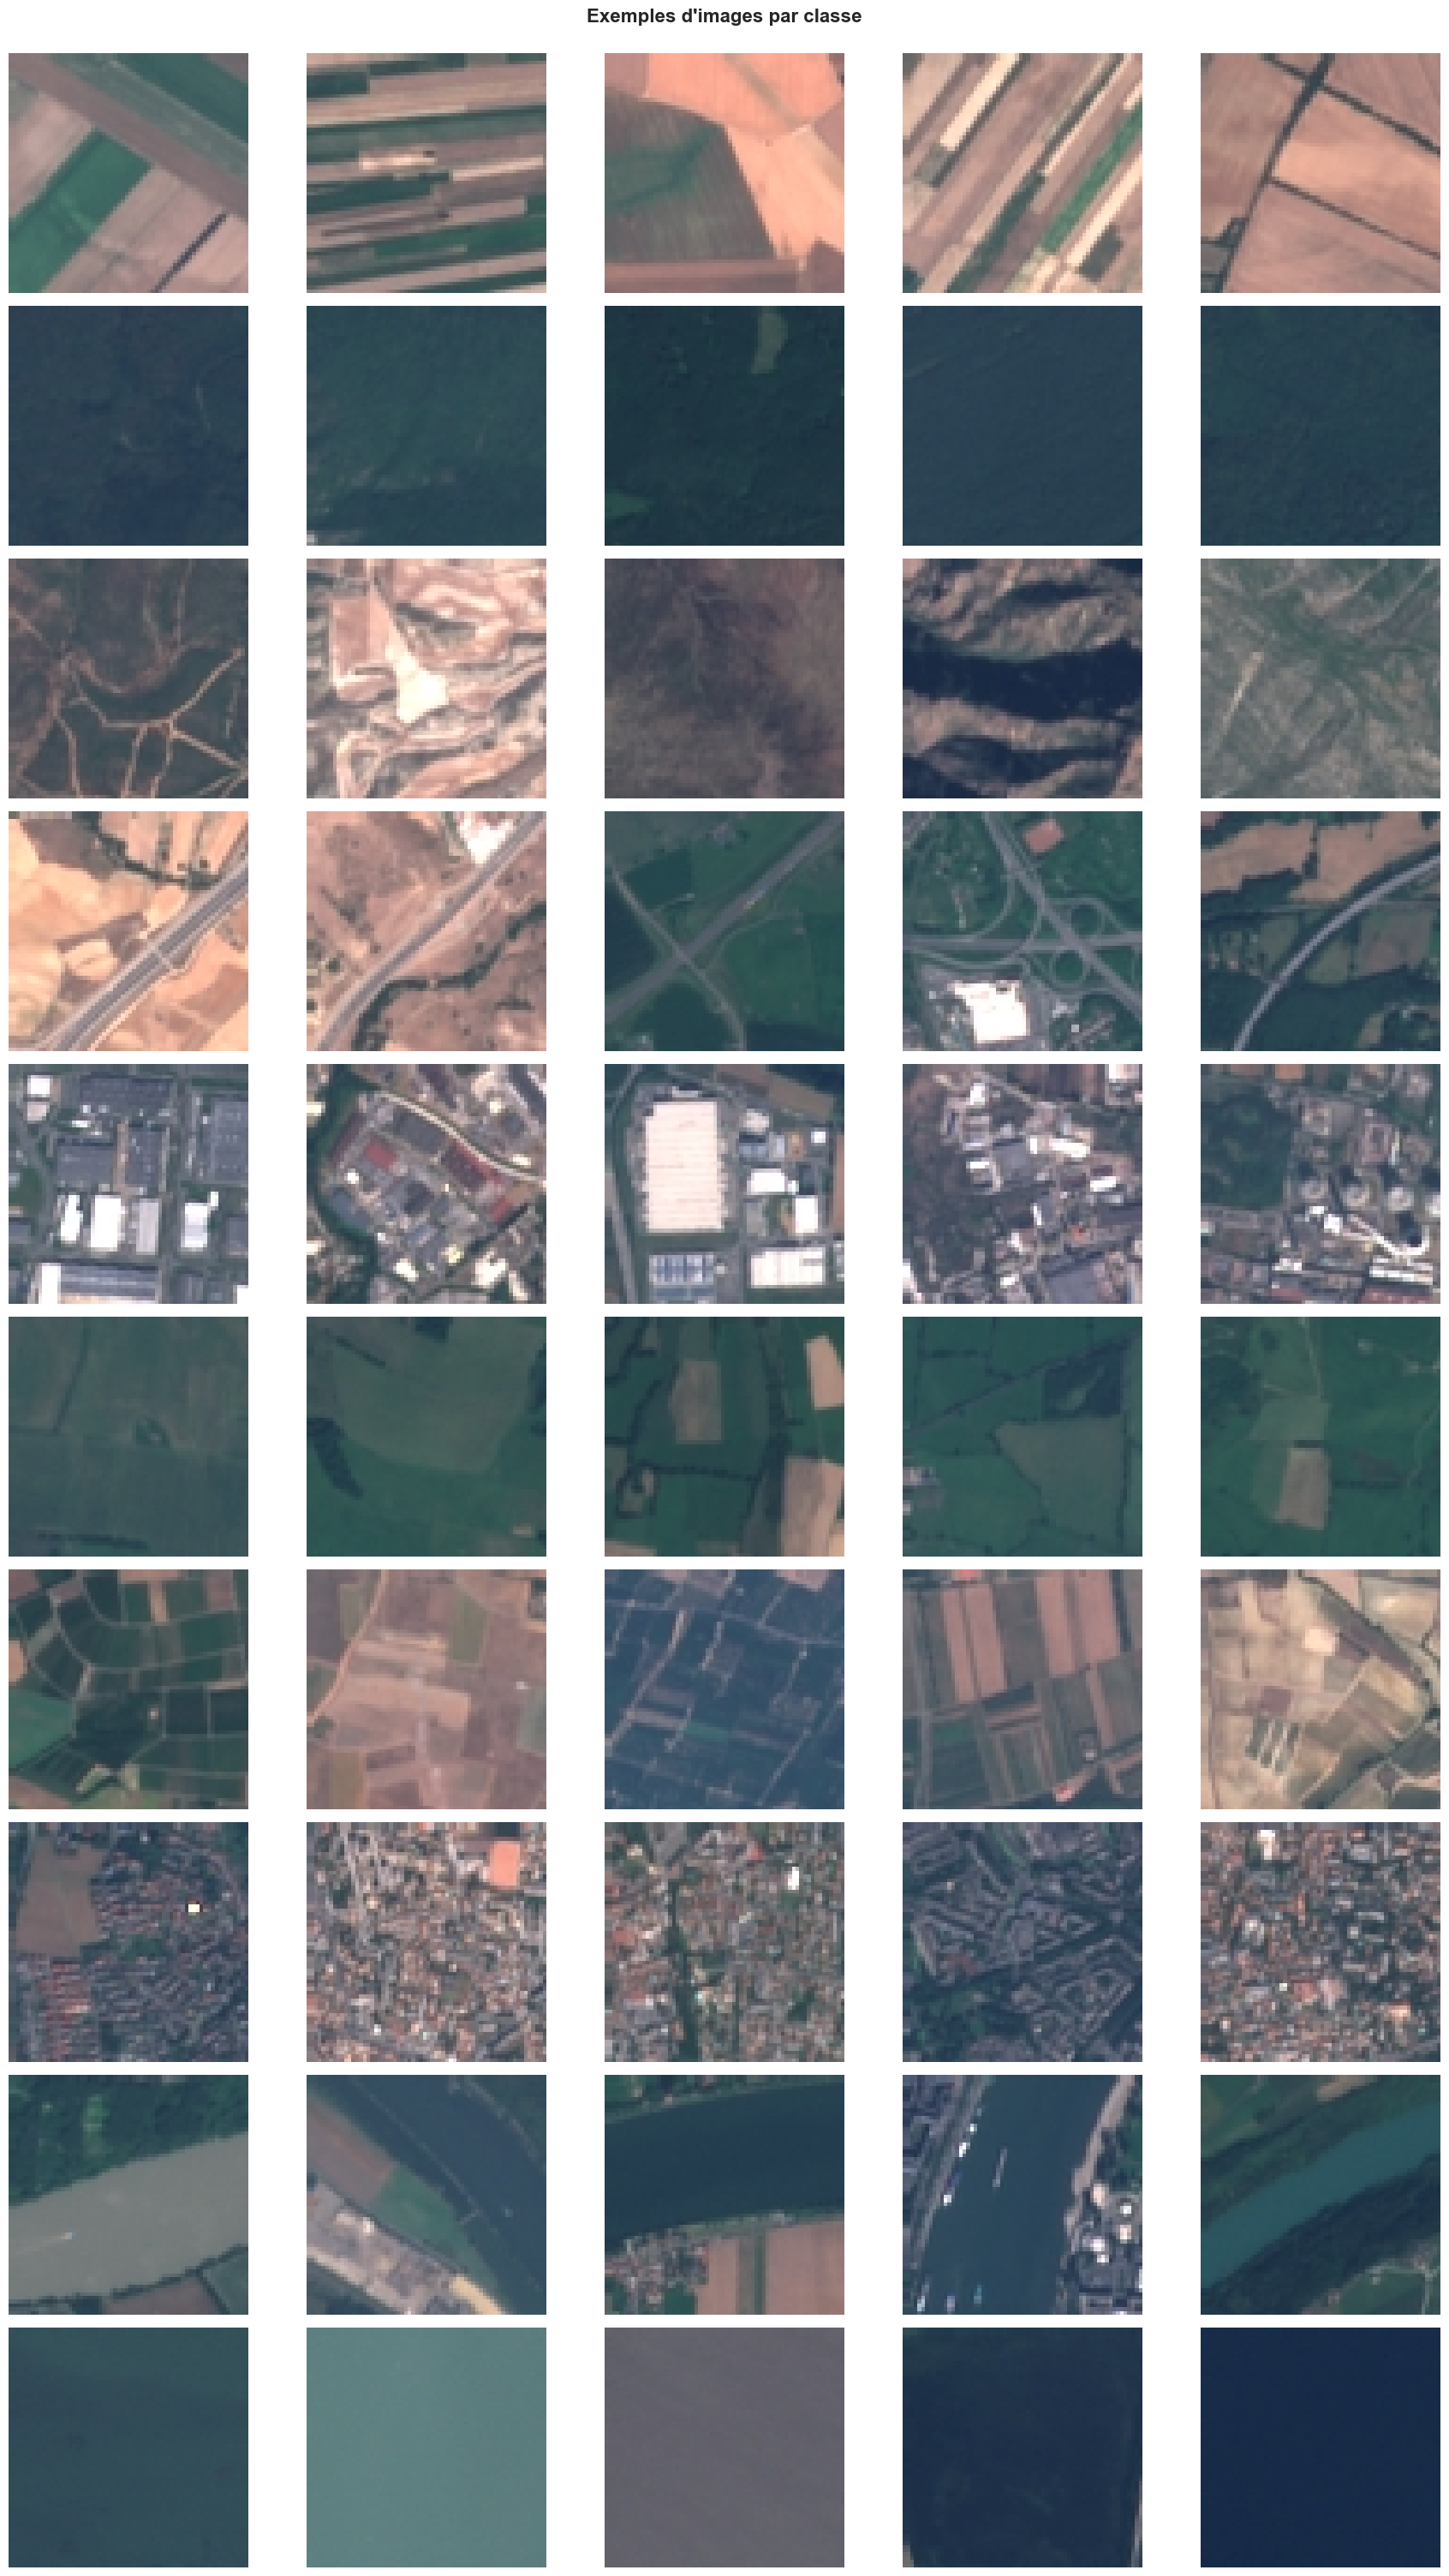


💡 Les images ont des tailles et orientations variées.
   Nous allons les redimensionner à 224x224 pour MobileNetV2.


In [9]:
# Visualiser quelques exemples de chaque classe
print("🌸 Exemples d'images du dataset\n")

# Utiliser les classes valides définies précédemment
valid_classes = sorted(class_names)

fig, axes = plt.subplots(len(valid_classes), 5, figsize=(18, 3*len(valid_classes)))

for i, class_name in enumerate(valid_classes):
    class_path = data_dir / class_name
    image_files = list(class_path.glob('*.jpg'))[:5]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.suptitle('Exemples d\'images par classe', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

print("\n💡 Les images ont des tailles et orientations variées.")
print("   Nous allons les redimensionner à 224x224 pour MobileNetV2.")

### 4.3 Préparation des datasets (Train/Val/Test)

In [10]:
print("🔧 Préparation des datasets...\n")

# Paramètres
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
VALIDATION_SPLIT = 0.2
SEED = 42

# IMPORTANT : Spécifier explicitement les classes valides pour éviter d'inclure des dossiers non-désirés
valid_class_names = sorted(class_names)


# Créer le dataset d'entraînement avec filtrage des classes
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # One-hot encoding pour multi-classe
    class_names=valid_class_names  # Spécifier explicitement les classes
)

# Créer le dataset de validation avec les mêmes classes
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=valid_class_names  # Même ordre de classes
)

# Obtenir les noms de classes (devrait être les 5 classes de fleurs)
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"✅ Datasets créés !\n")
print(f"📊 Information sur les datasets :")
print(f"  - Classes        : {class_names}")
print(f"  - Nombre de classes : {num_classes}")

# Vérification de sécurité
if num_classes != 10:
    print(f"\n⚠️  ERREUR : {num_classes} classes détectées au lieu de 10 !")
    print(f"   Classes trouvées : {class_names}")
else:
    print(f"  - ✅ Nombre de classes correct : 10")

print(f"\n  - Train batches  : {len(train_ds)}")
print(f"  - Val batches    : {len(val_ds)}")
print(f"  - Batch size     : {BATCH_SIZE}")
print(f"  - Image size     : {IMG_SIZE}")
print(f"\n  - Train samples  : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Val samples    : ~{len(val_ds) * BATCH_SIZE}")

🔧 Préparation des datasets...

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
✅ Datasets créés !

📊 Information sur les datasets :
  - Classes        : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  - Nombre de classes : 10
  - ✅ Nombre de classes correct : 10

  - Train batches  : 675
  - Val batches    : 169
  - Batch size     : 32
  - Image size     : (224, 224)

  - Train samples  : ~21600
  - Val samples    : ~5408


### 4.4 Prétraitement et Data Augmentation

**Prétraitement** :
- Normalisation : MobileNetV2 attend des valeurs entre -1 et 1
- Utilisation de `tf.keras.applications.mobilenet_v2.preprocess_input`

**Data Augmentation** (pour le training) :
- Rotation aléatoire
- Zoom aléatoire
- Flip horizontal
- Améliore la généralisation

In [11]:
print("🎨 Configuration du prétraitement et de la data augmentation...\n")

# Créer une fonction de prétraitement pour MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Créer un modèle d'augmentation de données plus agressif
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.1),  # Rotation jusqu'à 30%
    layers.RandomZoom(0.15),
], name="data_augmentation")

# Fonction pour appliquer le prétraitement
def prepare_dataset(ds, augment=False, shuffle=True):
    # Normalisation MobileNetV2
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Augmentation (seulement pour le train)
    if augment:
        augmentation = lambda x, y: (data_augmentation(x, training=True), y)
        ds = ds.map(augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle pour le training
    if shuffle:
        ds = ds.shuffle(1000)
    
    # Optimisation des performances
    #ds = ds.cache()  # Cache en mémoire
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch pour accélérer
    
    return ds

# Appliquer le prétraitement
train_ds_prepared = prepare_dataset(train_ds, augment=True, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, augment=False, shuffle=False)

print("✅ Prétraitement et augmentation configurés !\n")
print("📝 Transformations appliquées :")
print("  - Train : Normalisation + Augmentation (flip, rotation, zoom, contrast, translation, brightness)")
print("  - Val   : Normalisation seulement")
print("\n  - Shuffle, cache et prefetch activés pour les performances")

🎨 Configuration du prétraitement et de la data augmentation...

✅ Prétraitement et augmentation configurés !

📝 Transformations appliquées :
  - Train : Normalisation + Augmentation (flip, rotation, zoom, contrast, translation, brightness)
  - Val   : Normalisation seulement

  - Shuffle, cache et prefetch activés pour les performances


### 4.5 Visualisation de l'effet de l'augmentation

2026-06-01 15:59:35.381814: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-06-01 15:59:35.408000: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-06-01 15:59:35.472753: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-06-01 15:59:35.477953: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-06-01 15:59:35.499492: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-06-01 15:59:35.504001: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation

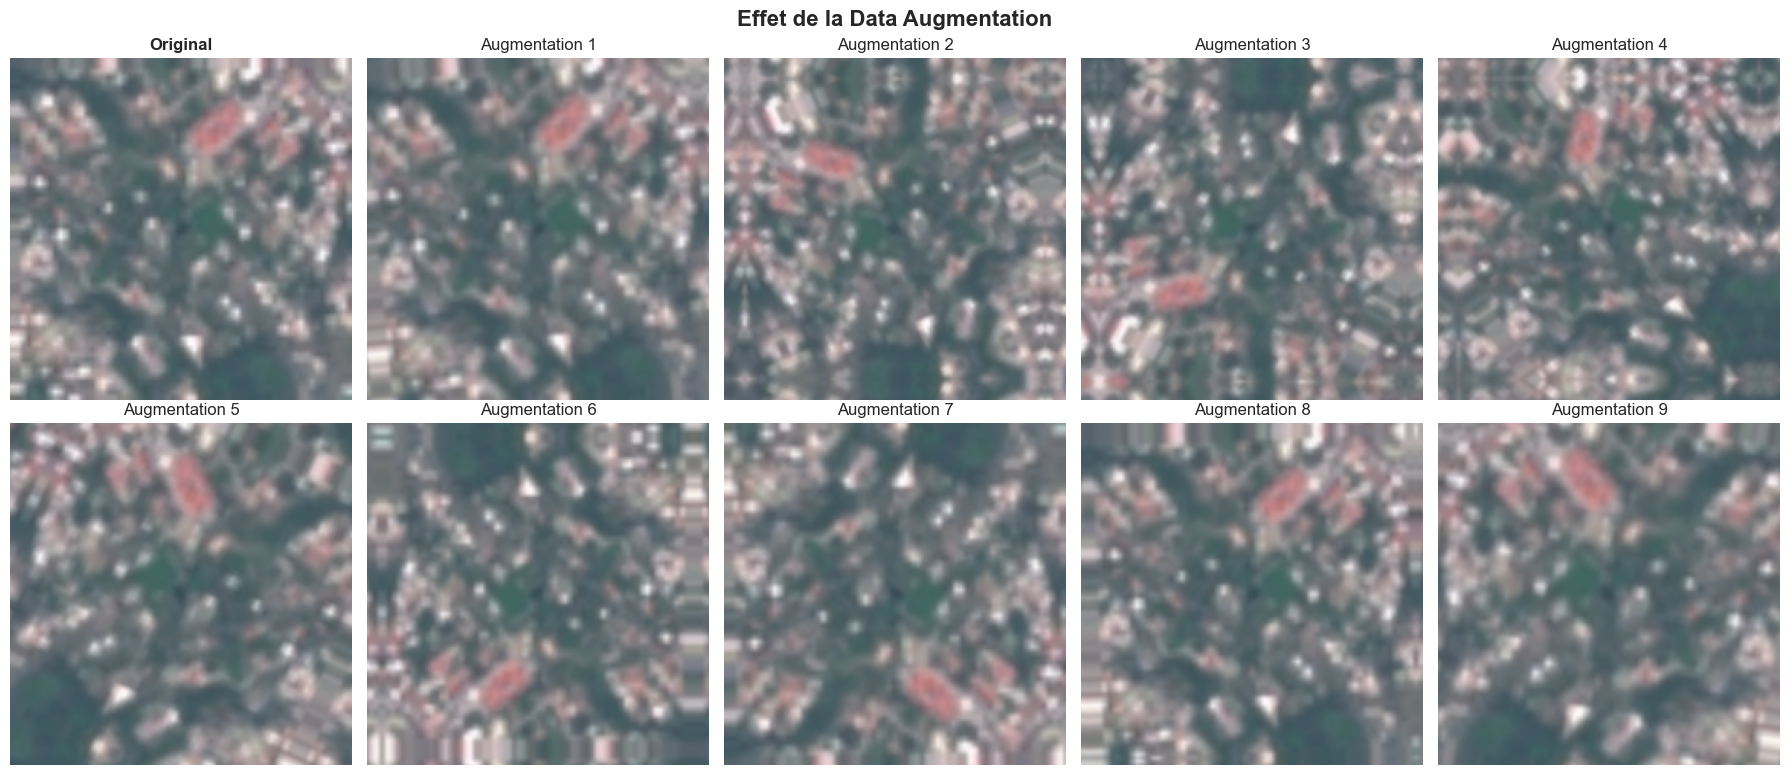


💡 L'augmentation crée des variations réalistes pour améliorer la robustesse du modèle.


In [12]:
# Prendre un batch d'exemples
for images, labels in train_ds.take(1):
    # Prendre la première image
    sample_image = images[1].numpy().astype("uint8")
    
    # Appliquer l'augmentation 9 fois
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()
    
    # Image originale
    axes[0].imshow(sample_image)
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Images augmentées
    for i in range(1, 10):
        augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        axes[i].imshow(augmented[0].numpy().astype("uint8"))
        axes[i].set_title(f'Augmentation {i}', fontsize=12)
        axes[i].axis('off')
    
    plt.suptitle('Effet de la Data Augmentation', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    break

print("\n💡 L'augmentation crée des variations réalistes pour améliorer la robustesse du modèle.")

## 5. Approche 1 : Feature Extraction (Modèle Frozen)

### 5.1 Principe

**Feature Extraction** consiste à :
1. **Geler** (freeze) toutes les couches du modèle pré-entraîné
2. **Ajouter** de nouvelles couches de classification
3. **Entraîner** seulement les nouvelles couches

**Avantages** :
- Très rapide (peu de paramètres à entraîner)
- Nécessite peu de données
- Pas de risque de dégrader les features pré-apprises

### 5.2 Construction du modèle frozen

In [13]:
print("🧊 Construction du modèle Feature Extraction (OPTIMISÉ)...\n")

# Geler le modèle de base
base_model.trainable = False

print(f"✅ Modèle de base gelé")
print(f"   {len(base_model.layers)} couches non-entraînables\n")

# Architecture OPTIMALE pour ce dataset
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Classifier avec régularisation modérée
x = layers.Dropout(0.3)(x)  # Dropout modéré
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_frozen = keras.Model(inputs, outputs, name='MobileNetV3_Frozen')

# Compiler avec LR optimal
model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),  # LR standard
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

print("✅ Modèle compilé !\n")

print("📊 Architecture :")
print("  Input(224,224,3) → MobileNetV3 → Dropout(0.3) → Dense(256,relu) → Dropout(0.3) → Dense(5,softmax)")

trainable = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
print(f"\n  - Paramètres entraînables    : {trainable:,}")
print(f"  - Paramètres non-entraînables: {non_trainable:,}")
print(f"  - Total                      : {trainable + non_trainable:,}")

print("\n💡 Configuration optimale :")
print("  - Learning rate : 0.001 (standard)")
print("  - Dropout       : 0.3 (modéré)")
print("  - Dense cachée  : 256 neurones")
print("  - L2 reg        : 0.01")

🧊 Construction du modèle Feature Extraction (OPTIMISÉ)...

✅ Modèle de base gelé
   230 couches non-entraînables

✅ Modèle compilé !

📊 Architecture :
  Input(224,224,3) → MobileNetV3 → Dropout(0.3) → Dense(256,relu) → Dropout(0.3) → Dense(5,softmax)

  - Paramètres entraînables    : 150,282
  - Paramètres non-entraînables: 939,120
  - Total                      : 1,089,402

💡 Configuration optimale :
  - Learning rate : 0.001 (standard)
  - Dropout       : 0.3 (modéré)
  - Dense cachée  : 256 neurones
  - L2 reg        : 0.01


### 5.3 Entraînement du modèle frozen

In [14]:
print("🚀 Entraînement du modèle frozen...\n")

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,  # Patience raisonnable
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model_frozen.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

EPOCHS_FROZEN = 15

print(f"Configuration :")
print(f"  - Epochs max : {EPOCHS_FROZEN}")
print(f"  - Patience   : 10 epochs")
print(f"  - LR initial : 0.001")
print(f"  - LR min     : 1e-7\n")

history_frozen = model_frozen.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FROZEN,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Entraînement frozen terminé !")
print(f"   Epochs effectués : {len(history_frozen.history['loss'])}")

best_val_acc = max(history_frozen.history['val_accuracy'])
best_epoch = history_frozen.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

if best_val_acc < 0.70:
    print(f"\n⚠️  Accuracy de {best_val_acc*100:.1f}% est en dessous de 70%")
    print("   Le modèle pourrait bénéficier de plus d'entraînement.")
elif best_val_acc < 0.80:
    print(f"\n✅ Bon résultat : {best_val_acc*100:.1f}%")
else:
    print(f"\n🎯 Excellent ! Accuracy de {best_val_acc*100:.1f}%")

🚀 Entraînement du modèle frozen...

Configuration :
  - Epochs max : 15
  - Patience   : 10 epochs
  - LR initial : 0.001
  - LR min     : 1e-7

Epoch 1/15


2026-06-01 15:59:36.874355: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-06-01 15:59:36.939270: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.
2026-06-01 15:59:47.001217: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:35: Filling up shuffle buffer (this may take a while): 572 of 1000
2026-06-01 15:59:48.997764: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


675/675 [==============================] - 49s 53ms/step - loss: 2.5671 - accuracy: 0.1352 - top2_accuracy: 0.2503 - val_loss: 2.2719 - val_accuracy: 0.1594 - val_top2_accuracy: 0.3607 - lr: 0.0010
Epoch 2/15


2026-06-01 16:00:35.424576: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:35: Filling up shuffle buffer (this may take a while): 508 of 1000


  2/675 [..............................] - ETA: 33s - loss: 2.3596 - accuracy: 0.1562 - top2_accuracy: 0.2188    

2026-06-01 16:00:39.246954: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


675/675 [==============================] - 54s 60ms/step - loss: 2.2458 - accuracy: 0.1821 - top2_accuracy: 0.3148 - val_loss: 2.1826 - val_accuracy: 0.2172 - val_top2_accuracy: 0.4080 - lr: 0.0010
Epoch 3/15


2026-06-01 16:01:29.885480: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:35: Filling up shuffle buffer (this may take a while): 405 of 1000
2026-06-01 16:01:38.345640: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


508/675 [=====================>........] - ETA: 10s - loss: 2.1838 - accuracy: 0.2050 - top2_accuracy: 0.3545

KeyboardInterrupt: 

### 5.4 Évaluation du modèle frozen

### 5.3.5 🔍 Diagnostic - Vérification des prédictions

Avant de passer au fine-tuning, vérifions que le modèle frozen apprend correctement.

In [ ]:
print("🔍 Diagnostic du modèle frozen\n")
print("="*80)

# Obtenir quelques prédictions sur le validation set
for images, labels in val_ds_prepared.take(1):
    predictions = model_frozen.predict(images[:5], verbose=0)
    
    print("\n📊 Échantillon de prédictions :")
    print("-"*80)
    
    for i in range(5):
        true_label = np.argmax(labels[i])
        pred_label = np.argmax(predictions[i])
        confidence = predictions[i][pred_label]
        
        status = "✅" if true_label == pred_label else "❌"
        print(f"{status} Image {i+1}: Vrai={class_names[true_label]:12s} | Prédit={class_names[pred_label]:12s} | Conf={confidence*100:5.1f}%")

print("\n" + "="*80)
print("\n💡 Si beaucoup de prédictions sont incorrectes, vérifiez :")
print("   1. Le preprocessing est correct (preprocess_input pour MobileNetV2)")
print("   2. Le modèle a été entraîné suffisamment longtemps")
print("   3. Le learning rate n'est pas trop faible")
print("\n⚠️  Si l'accuracy frozen est < 70%, le fine-tuning ne sera pas efficace !")

🔍 Diagnostic du modèle frozen


📊 Échantillon de prédictions :
--------------------------------------------------------------------------------
✅ Image 1: Vrai=Residential  | Prédit=Residential  | Conf= 93.3%
✅ Image 2: Vrai=River        | Prédit=River        | Conf= 88.9%
✅ Image 3: Vrai=AnnualCrop   | Prédit=AnnualCrop   | Conf= 97.9%
✅ Image 4: Vrai=Residential  | Prédit=Residential  | Conf= 99.8%
✅ Image 5: Vrai=Industrial   | Prédit=Industrial   | Conf= 97.9%


💡 Si beaucoup de prédictions sont incorrectes, vérifiez :
   1. Le preprocessing est correct (preprocess_input pour MobileNetV2)
   2. Le modèle a été entraîné suffisamment longtemps
   3. Le learning rate n'est pas trop faible

⚠️  Si l'accuracy frozen est < 70%, le fine-tuning ne sera pas efficace !


📊 Évaluation du modèle frozen sur validation...

Résultats :
  - Loss                : 0.4003
  - Accuracy            : 91.96%
  - Top-2 Accuracy      : 97.83%


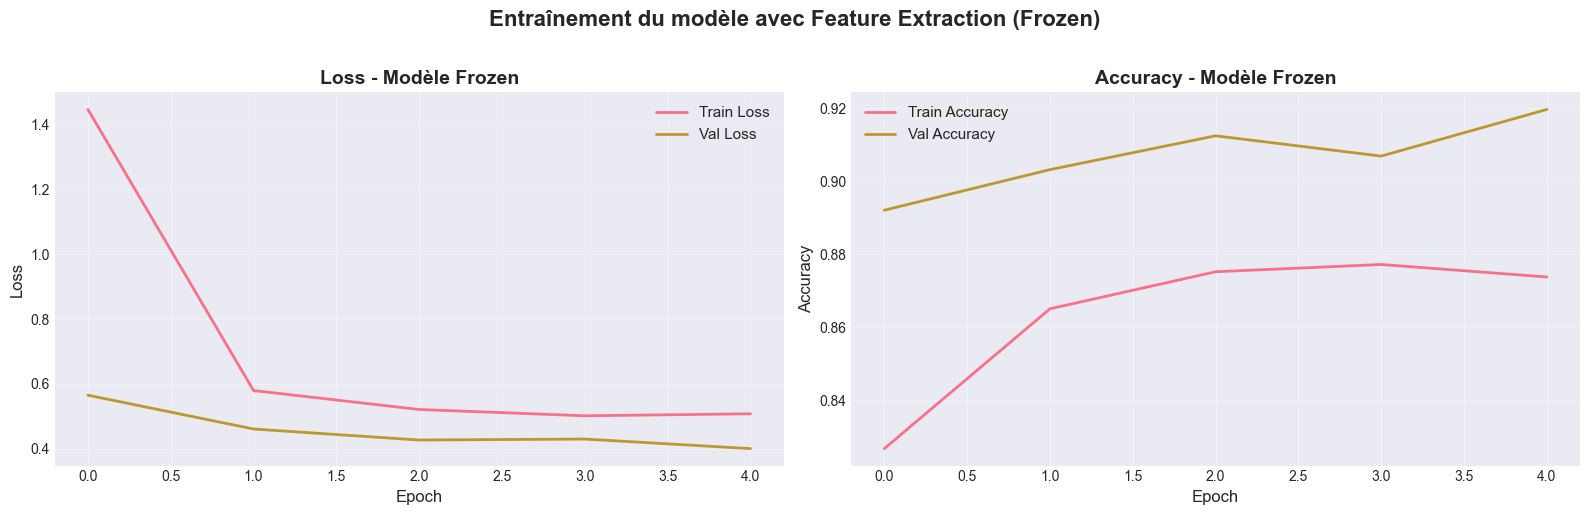


💡 Le modèle frozen donne déjà de bons résultats !
   Voyons maintenant si le fine-tuning peut améliorer les performances.


In [ ]:
# Évaluation sur validation
print("📊 Évaluation du modèle frozen sur validation...\n")

results_frozen = model_frozen.evaluate(val_ds_prepared, verbose=0)

print("Résultats :")
print(f"  - Loss                : {results_frozen[0]:.4f}")
print(f"  - Accuracy            : {results_frozen[1]*100:.2f}%")
print(f"  - Top-2 Accuracy      : {results_frozen[2]*100:.2f}%")

# Visualiser les courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_frozen.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_frozen.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss - Modèle Frozen', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_frozen.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_frozen.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy - Modèle Frozen', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Entraînement du modèle avec Feature Extraction (Frozen)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Le modèle frozen donne déjà de bons résultats !")
print("   Voyons maintenant si le fine-tuning peut améliorer les performances.")

## 6. Approche 2 : Fine-Tuning (Modèle Unfrozen)

### 6.1 Principe

**Fine-Tuning** consiste à :
1. **Dégeler** (unfreeze) certaines ou toutes les couches du modèle
2. **Ré-entraîner** avec un learning rate très faible
3. **Adapter** les features aux données spécifiques

**Stratégie de fine-tuning** :
- Dégeler seulement les dernières couches (high-level features)
- Garder frozen les premières couches (low-level features comme edges, textures)
- Utiliser un learning rate 10-100x plus faible

### 6.2 Construction du modèle fine-tuned

In [ ]:
print("🔥 Préparation du Fine-Tuning (Approche Directe et Simple)...\n")

# APPROCHE LA PLUS SIMPLE : Modifier le modèle frozen en place
print("💡 Stratégie : Dégeler le base_model et continuer l'entraînement\n")

# Évaluation AVANT fine-tuning
print("📈 Performance AVANT fine-tuning :")
results_before = model_frozen.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

# Dégeler le base_model
base_model.trainable = True

# Geler seulement les 100 premières couches
fine_tune_at = 100

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print(f"📊 Configuration du dégel :")
print(f"  - Couches frozen  : {fine_tune_at}")
print(f"  - Couches unfrozen: {len(base_model.layers) - fine_tune_at}")

# Compter les paramètres
trainable_count = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"  - Paramètres entraînables : {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"  - Paramètres frozen       : {non_trainable_count:,}\n")

# Recompiler avec un LR très faible
FINE_TUNE_LR = 1e-5  # LR très faible

model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

# Le modèle fine-tuned est le modèle frozen modifié
model_finetuned = model_frozen

print(f"✅ Modèle recompilé avec LR = {FINE_TUNE_LR}")
print("\n💡 Le modèle va continuer depuis les poids déjà appris.")

# Vérification immédiate
print("\n🔍 Vérification immédiate :")
results_after_compile = model_finetuned.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

🔥 Préparation du Fine-Tuning (Approche Directe et Simple)...

💡 Stratégie : Dégeler le base_model et continuer l'entraînement

📈 Performance AVANT fine-tuning :


  - Accuracy : 91.96%
  - Loss     : 0.4003

📊 Configuration du dégel :
  - Couches frozen  : 100
  - Couches unfrozen: 55
  - Paramètres entraînables : 2,191,946 (84.7%)
  - Paramètres frozen       : 396,544

✅ Modèle recompilé avec LR = 1e-05

💡 Le modèle va continuer depuis les poids déjà appris.

🔍 Vérification immédiate :
  - Accuracy : 91.96%
  - Loss     : 0.4003

  ✅ Parfait ! Les poids sont préservés (92.0%)


: 

### 6.3 Entraînement du modèle fine-tuned

In [ ]:
print("🚀 Fine-tuning du modèle...\n")
print("⚠️  Le modèle continue depuis les poids frozen déjà entraînés\n")

# Callbacks pour fine-tuning
early_stopping_ft = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,  # Beaucoup de patience
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-8,
    verbose=1
)

checkpoint_ft = callbacks.ModelCheckpoint(
    'best_model_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

# Entraînement
EPOCHS_FINETUNE = 5

print(f"Entraînement pour {EPOCHS_FINETUNE} epochs maximum...\n")

history_finetuned = model_finetuned.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft],
    verbose=1
)

print("\n✅ Fine-tuning terminé !")
print(f"   Nombre d'epochs effectués : {len(history_finetuned.history['loss'])}")

# Meilleures performances
best_val_acc = max(history_finetuned.history['val_accuracy'])
best_epoch = history_finetuned.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

# Comparaison
frozen_best = max(history_frozen.history['val_accuracy'])
improvement = (best_val_acc - frozen_best) * 100
print(f"\n📊 Amélioration vs Frozen : {improvement:+.2f} points de pourcentage")
print(f"   - Frozen    : {frozen_best*100:.2f}%")
print(f"   - Fine-tuned: {best_val_acc*100:.2f}%")

🚀 Fine-tuning du modèle...

⚠️  Le modèle continue depuis les poids frozen déjà entraînés

Entraînement pour 50 epochs maximum...

Epoch 1/50


### 6.4 Évaluation du modèle fine-tuned

📊 Évaluation du modèle fine-tuned sur validation...

Résultats :
  - Loss                : 0.3817
  - Accuracy            : 90.87%
  - Top-2 Accuracy      : 96.87%


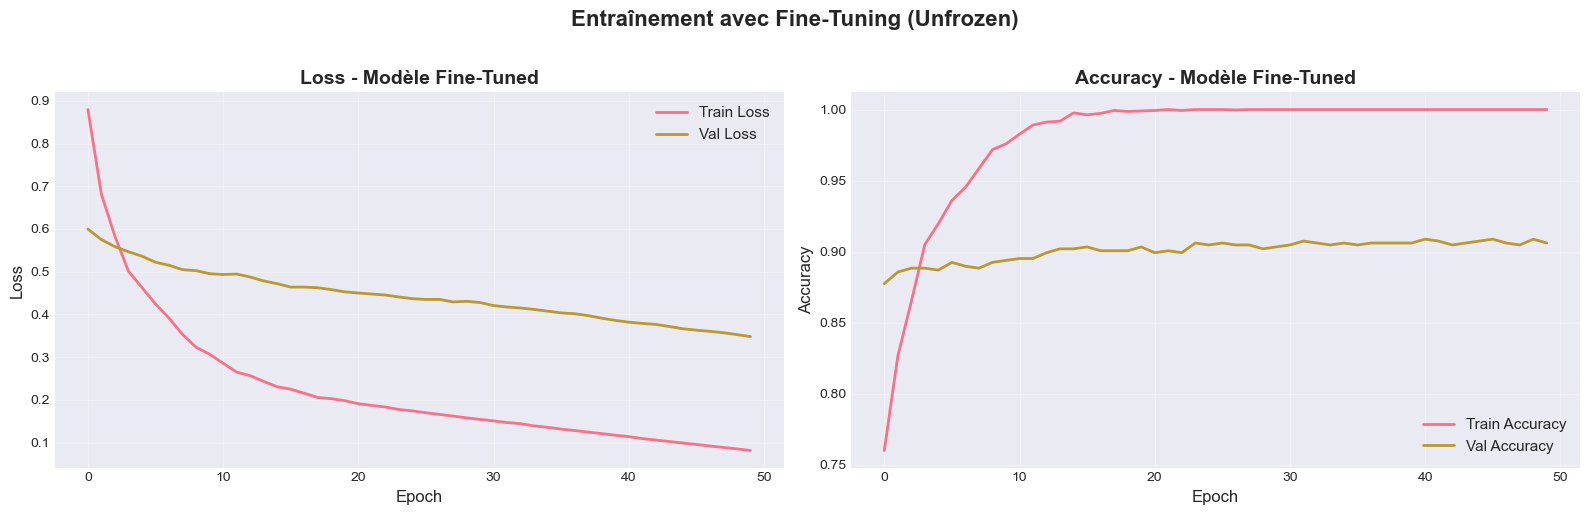


💡 Le fine-tuning a-t-il amélioré les performances ?
   Comparons les deux approches...


In [ ]:
# Évaluation sur validation
print("📊 Évaluation du modèle fine-tuned sur validation...\n")

results_finetuned = model_finetuned.evaluate(val_ds_prepared, verbose=0)

print("Résultats :")
print(f"  - Loss                : {results_finetuned[0]:.4f}")
print(f"  - Accuracy            : {results_finetuned[1]*100:.2f}%")
print(f"  - Top-2 Accuracy      : {results_finetuned[2]*100:.2f}%")

# Visualiser les courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_finetuned.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_finetuned.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss - Modèle Fine-Tuned', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_finetuned.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_finetuned.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy - Modèle Fine-Tuned', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Entraînement avec Fine-Tuning (Unfrozen)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Le fine-tuning a-t-il amélioré les performances ?")
print("   Comparons les deux approches...")

## 7. Comparaison des Deux Approches

### 7.1 Métriques comparatives

In [ ]:
print("📊 COMPARAISON : Feature Extraction vs Fine-Tuning\n")
print("="*80)

# Créer un DataFrame comparatif
comparison_data = {
    'Métrique': ['Val Loss', 'Val Accuracy', 'Val Top-2 Accuracy'],
    'Feature Extraction (Frozen)': [
        f"{results_frozen[0]:.4f}",
        f"{results_frozen[1]*100:.2f}%",
        f"{results_frozen[2]*100:.2f}%"
    ],
    'Fine-Tuning (Unfrozen)': [
        f"{results_finetuned[0]:.4f}",
        f"{results_finetuned[1]*100:.2f}%",
        f"{results_finetuned[2]*100:.2f}%"
    ],
    'Amélioration': [
        f"{(results_frozen[0] - results_finetuned[0]):.4f}",
        f"{(results_finetuned[1] - results_frozen[1])*100:.2f}%",
        f"{(results_finetuned[2] - results_frozen[2])*100:.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("\n" + "="*80)

# Informations supplémentaires
print("\n🔍 Analyse :")
if results_finetuned[1] > results_frozen[1]:
    improvement = (results_finetuned[1] - results_frozen[1]) * 100
    print(f"  ✅ Le fine-tuning améliore l'accuracy de {improvement:.2f}% !")
    print("     → Les features adaptées donnent de meilleurs résultats.")
else:
    print("  ⚠️  Le feature extraction performe aussi bien ou mieux.")
    print("     → Cela peut arriver avec peu de données ou si les features ImageNet sont suffisantes.")

print("\n📈 Temps d'entraînement approximatif :")
print(f"  - Feature Extraction : ~{len(history_frozen.history['loss'])} epochs")
print(f"  - Fine-Tuning        : ~{len(history_finetuned.history['loss'])} epochs")

print("\n💡 Le fine-tuning est généralement meilleur mais plus lent et nécessite plus de données.")

📊 COMPARAISON : Feature Extraction vs Fine-Tuning

          Métrique Feature Extraction (Frozen) Fine-Tuning (Unfrozen) Amélioration
          Val Loss                      0.6141                 0.3817       0.2324
      Val Accuracy                      88.01%                 90.87%        2.86%
Val Top-2 Accuracy                      96.19%                 96.87%        0.68%


🔍 Analyse :
  ✅ Le fine-tuning améliore l'accuracy de 2.86% !
     → Les features adaptées donnent de meilleurs résultats.

📈 Temps d'entraînement approximatif :
  - Feature Extraction : ~18 epochs
  - Fine-Tuning        : ~50 epochs

💡 Le fine-tuning est généralement meilleur mais plus lent et nécessite plus de données.


### 7.2 Visualisation comparative

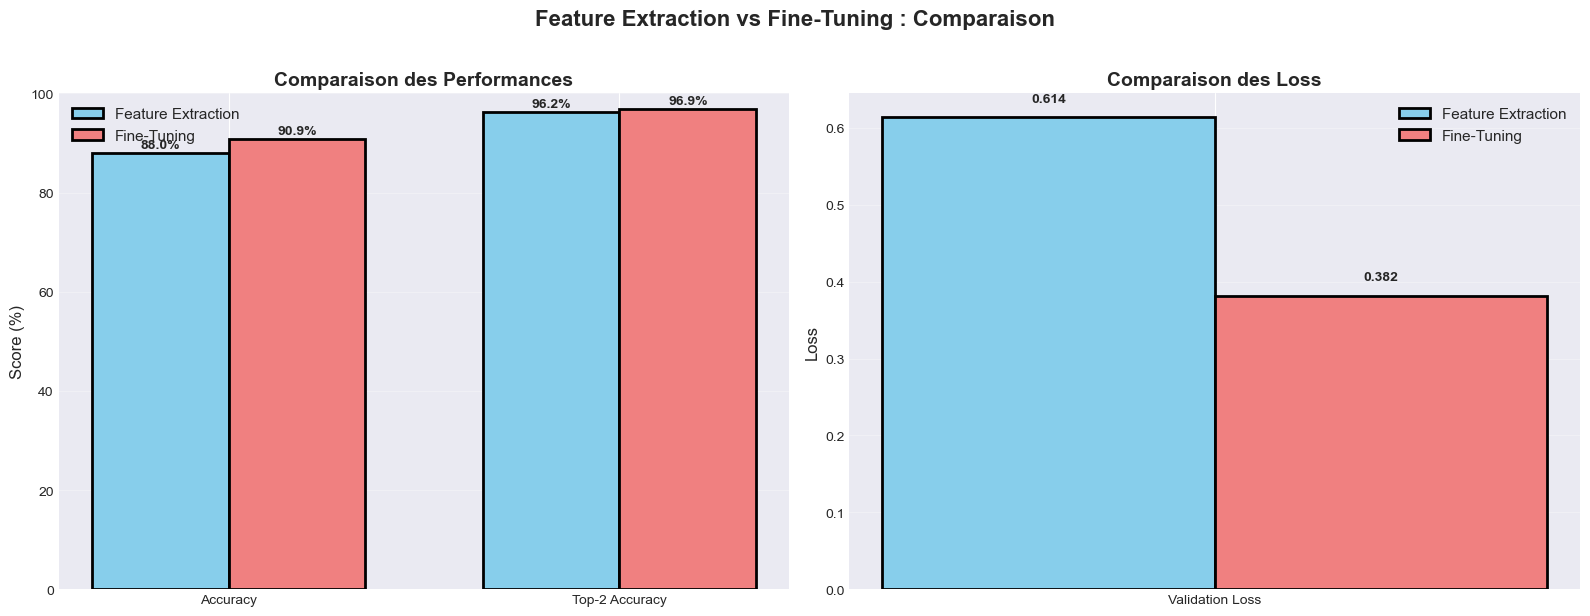

In [ ]:
# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparaison des accuracies
metrics = ['Accuracy', 'Top-2 Accuracy']
frozen_scores = [results_frozen[1]*100, results_frozen[2]*100]
finetuned_scores = [results_finetuned[1]*100, results_finetuned[2]*100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, frozen_scores, width, label='Feature Extraction', color='skyblue', edgecolor='black', linewidth=2)
axes[0].bar(x + width/2, finetuned_scores, width, label='Fine-Tuning', color='lightcoral', edgecolor='black', linewidth=2)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('Comparaison des Performances', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0, 100])

# Ajouter les valeurs sur les barres
for i, (f, ft) in enumerate(zip(frozen_scores, finetuned_scores)):
    axes[0].text(i - width/2, f + 1, f'{f:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, ft + 1, f'{ft:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Comparaison des loss
categories = ['Validation Loss']
frozen_loss = [results_frozen[0]]
finetuned_loss = [results_finetuned[0]]

x2 = np.arange(len(categories))
axes[1].bar(x2 - width/2, frozen_loss, width, label='Feature Extraction', color='skyblue', edgecolor='black', linewidth=2)
axes[1].bar(x2 + width/2, finetuned_loss, width, label='Fine-Tuning', color='lightcoral', edgecolor='black', linewidth=2)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Comparaison des Loss', fontsize=14, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

# Ajouter les valeurs
axes[1].text(x2[0] - width/2, frozen_loss[0] + 0.02, f'{frozen_loss[0]:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].text(x2[0] + width/2, finetuned_loss[0] + 0.02, f'{finetuned_loss[0]:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Feature Extraction vs Fine-Tuning : Comparaison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Matrice de Confusion et Analyse Détaillée

### 8.1 Matrice de confusion pour le modèle fine-tuned

📊 Analyse détaillée avec matrice de confusion...



2025-11-13 15:40:30.381976: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


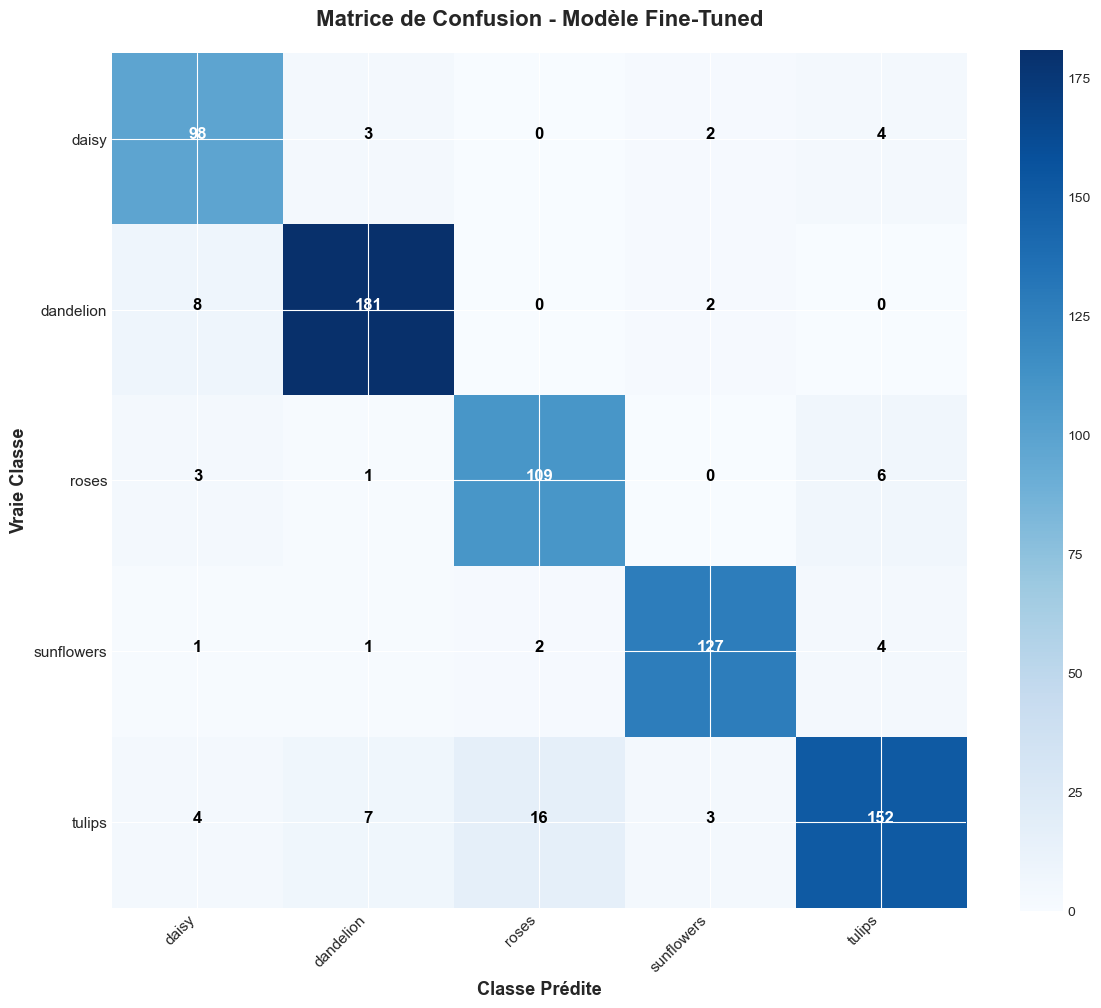


📄 Rapport de classification détaillé :

              precision    recall  f1-score   support

       daisy      0.860     0.916     0.887       107
   dandelion      0.938     0.948     0.943       191
       roses      0.858     0.916     0.886       119
  sunflowers      0.948     0.941     0.944       135
      tulips      0.916     0.835     0.874       182

    accuracy                          0.909       734
   macro avg      0.904     0.911     0.907       734
weighted avg      0.910     0.909     0.909       734



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

print("📊 Analyse détaillée avec matrice de confusion...\n")

# Obtenir les prédictions
y_true = []
y_pred = []

for images, labels in val_ds_prepared:
    predictions = model_finetuned.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Visualiser
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice de Confusion - Modèle Fine-Tuned', fontsize=16, fontweight='bold', pad=20)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right', fontsize=11)
plt.yticks(tick_marks, class_names, fontsize=11)

# Ajouter les valeurs dans les cellules
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black",
             fontsize=12, fontweight='bold')

plt.ylabel('Vraie Classe', fontsize=13, fontweight='bold')
plt.xlabel('Classe Prédite', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Rapport de classification
print("\n📄 Rapport de classification détaillé :\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

### 8.2 Analyse par classe

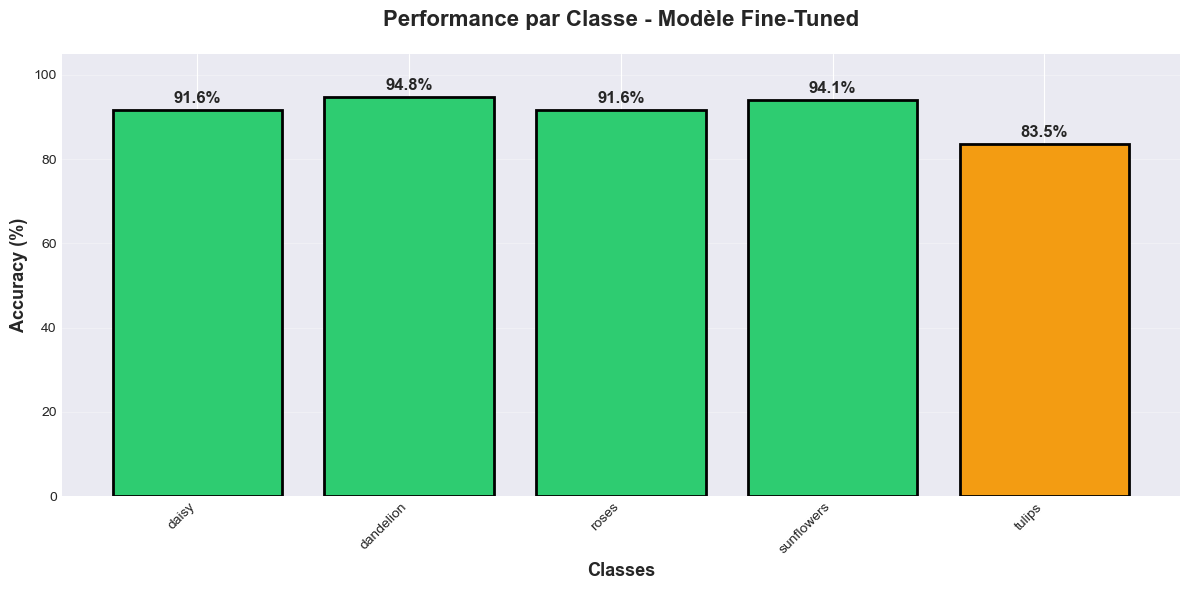


🏆 Meilleure classe  : dandelion (94.8%)
⚠️  Pire classe      : tulips (83.5%)


In [ ]:
# Calculer l'accuracy par classe
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Visualiser
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if acc > 0.85 else '#f39c12' if acc > 0.75 else '#e74c3c' for acc in class_accuracies]
bars = ax.bar(class_names, class_accuracies * 100, color=colors, edgecolor='black', linewidth=2)

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc*100:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Classes', fontsize=13, fontweight='bold')
ax.set_title('Performance par Classe - Modèle Fine-Tuned', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim([0, 105])
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identifier les meilleures et pires classes
best_class_idx = np.argmax(class_accuracies)
worst_class_idx = np.argmin(class_accuracies)

print(f"\n🏆 Meilleure classe  : {class_names[best_class_idx]} ({class_accuracies[best_class_idx]*100:.1f}%)")
print(f"⚠️  Pire classe      : {class_names[worst_class_idx]} ({class_accuracies[worst_class_idx]*100:.1f}%)")

## 9. Prédictions sur Nouvelles Images

### 9.1 Fonction de prédiction

In [ ]:
def predict_image(model, image_path, class_names):
    """
    Prédit la classe d'une image avec le modèle.
    
    Args:
        model: Modèle Keras entraîné
        image_path: Chemin vers l'image
        class_names: Liste des noms de classes
    """
    # Charger et prétraiter l'image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Ajouter dimension batch
    img_array = preprocess_input(img_array)  # Normalisation MobileNetV2
    
    # Prédire
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    
    # Top 3 prédictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    
    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'all_probabilities': predictions[0],
        'top3': [(class_names[i], predictions[0][i]) for i in top3_idx]
    }

print("✅ Fonction de prédiction créée !")

✅ Fonction de prédiction créée !


### 9.2 Prédictions sur images de test

🔮 Prédictions sur images de test...



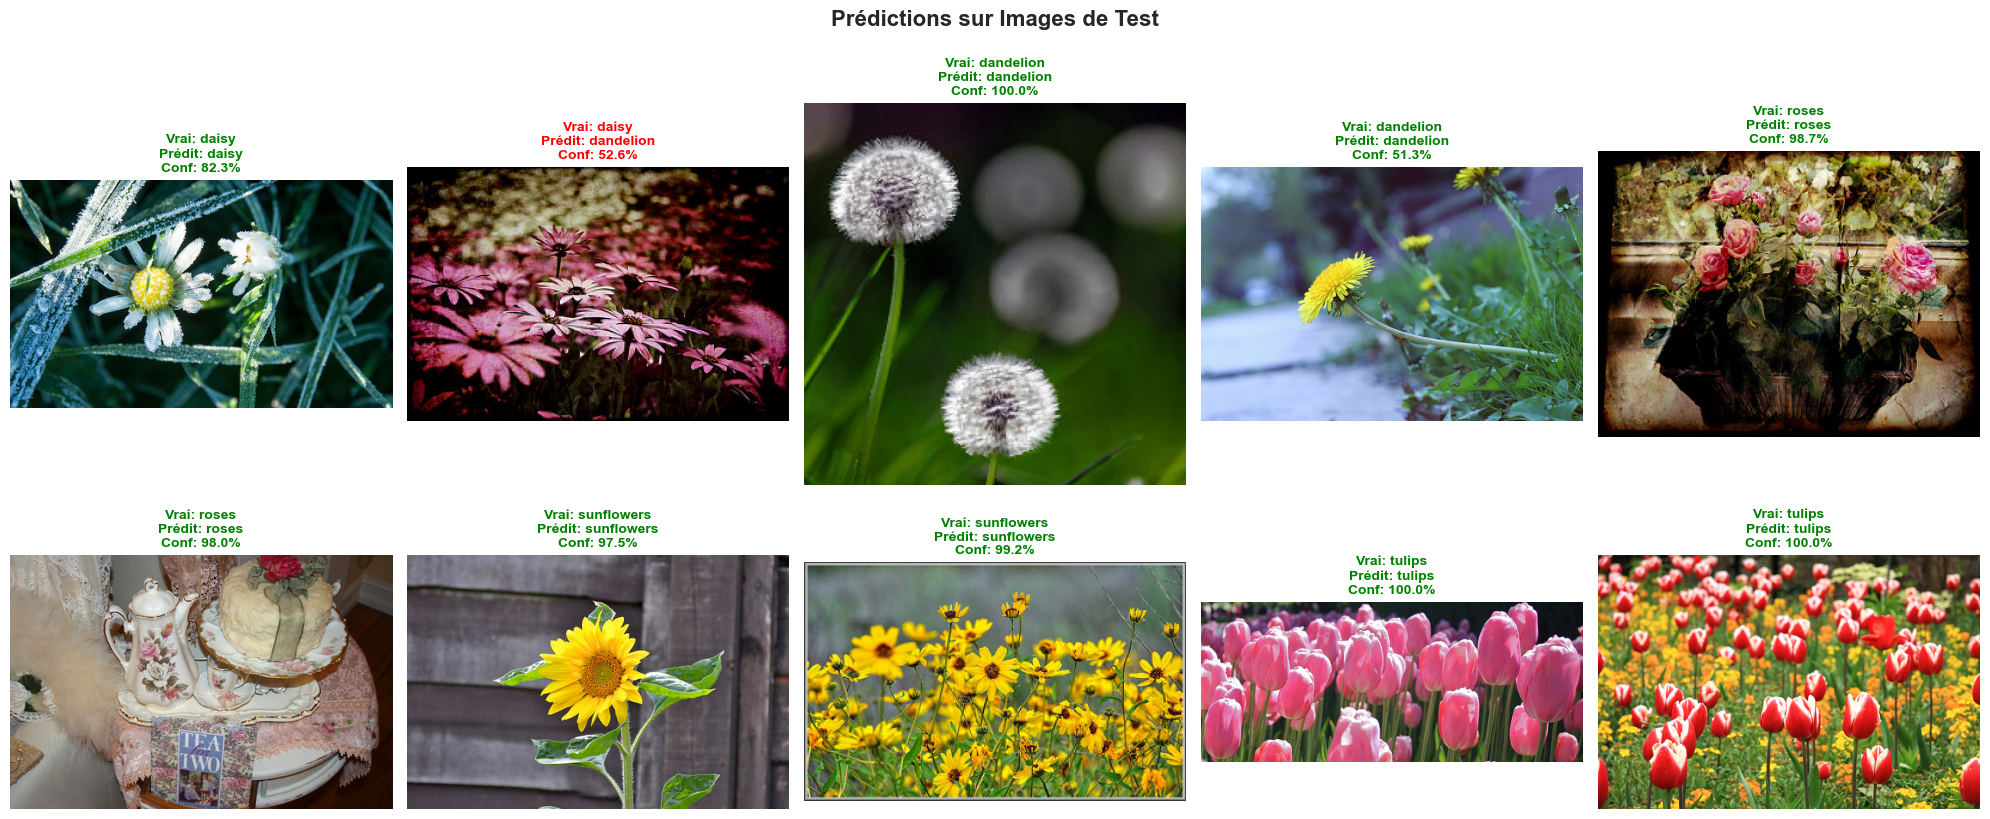


💡 Les bordures vertes indiquent des prédictions correctes, les rouges des erreurs.


In [ ]:
print("🔮 Prédictions sur images de test...\n")

# Sélectionner quelques images aléatoires
import random

test_images = []
for class_name in class_names:
    class_path = data_dir / class_name
    images = list(class_path.glob('*.jpg'))
    # Prendre 2 images aléatoires de chaque classe
    test_images.extend(random.sample(images, min(2, len(images))))

# Faire des prédictions
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for idx, img_path in enumerate(test_images[:10]):
    # Prédire
    result = predict_image(model_finetuned, img_path, class_names)
    
    # Afficher l'image
    img = plt.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Vraie classe (depuis le nom du dossier)
    true_class = img_path.parent.name
    predicted_class = result['predicted_class']
    confidence = result['confidence']
    
    # Couleur : vert si correct, rouge si incorrect
    color = 'green' if true_class == predicted_class else 'red'
    
    # Titre
    title = f"Vrai: {true_class}\nPrédit: {predicted_class}\nConf: {confidence*100:.1f}%"
    axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')

plt.suptitle('Prédictions sur Images de Test', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print("\n💡 Les bordures vertes indiquent des prédictions correctes, les rouges des erreurs.")

### 9.3 Visualisation des probabilités pour une image

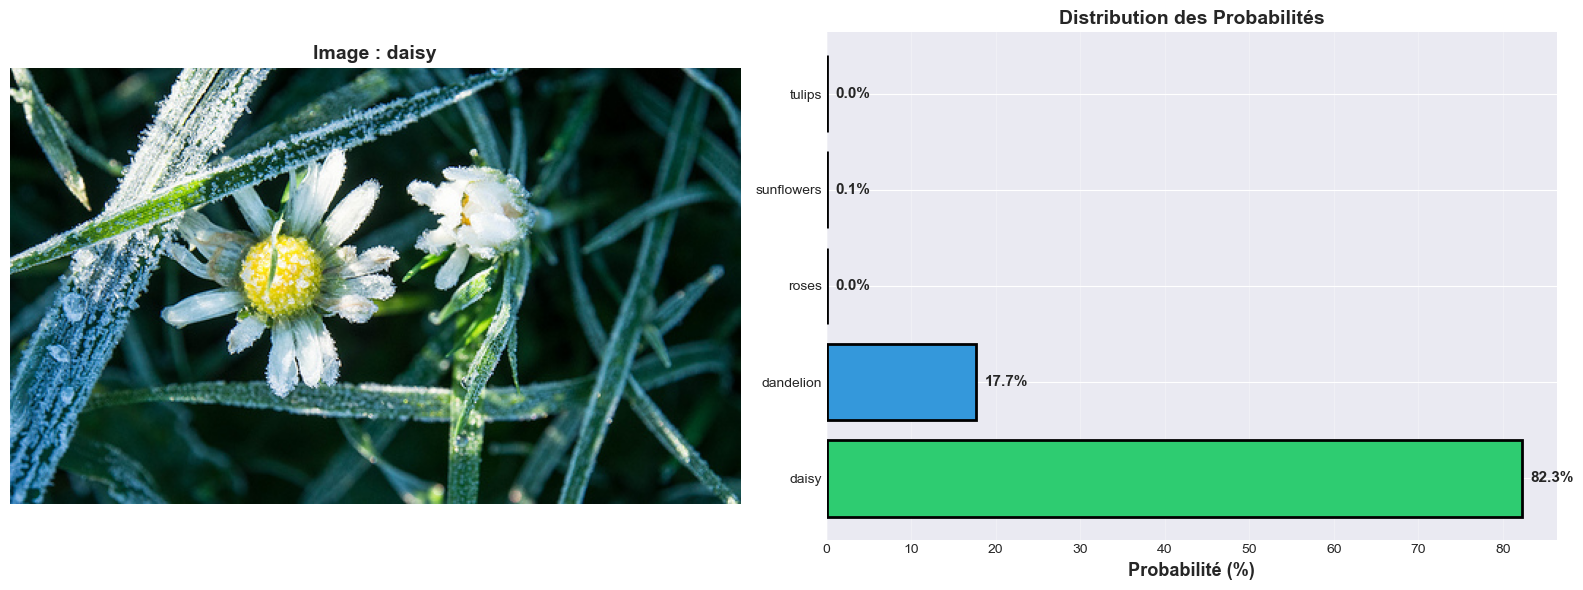


🔍 Analyse de la prédiction :
  - Classe prédite : daisy
  - Confiance      : 82.27%

  - Top 3 prédictions :
    1. daisy           : 82.27%
    2. dandelion       : 17.65%
    3. sunflowers      : 0.07%


In [ ]:
# Prendre une image spécifique
sample_image_path = test_images[0]
result = predict_image(model_finetuned, sample_image_path, class_names)

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Image
img = plt.imread(sample_image_path)
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f"Image : {sample_image_path.parent.name}", fontsize=14, fontweight='bold')

# Probabilités
probs = result['all_probabilities'] * 100
colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

bars = axes[1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Probabilité (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Distribution des Probabilités', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Ajouter les valeurs
for bar, prob in zip(bars, probs):
    width = bar.get_width()
    axes[1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                f'{prob:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 Analyse de la prédiction :")
print(f"  - Classe prédite : {result['predicted_class']}")
print(f"  - Confiance      : {result['confidence']*100:.2f}%")
print(f"\n  - Top 3 prédictions :")
for i, (cls, prob) in enumerate(result['top3'], 1):
    print(f"    {i}. {cls:15s} : {prob*100:.2f}%")

## 10. Sauvegarde et Chargement du Modèle

### 10.1 Sauvegarde

In [ ]:
print("💾 Sauvegarde du modèle fine-tuned...\n")

# Sauvegarder au format Keras (.keras)
model_path = 'mobilenetv2_flowers_finetuned.keras'
model_finetuned.save(model_path)

print(f"✅ Modèle sauvegardé : {model_path}")
print(f"   Taille du fichier : {os.path.getsize(model_path) / (1024**2):.1f} MB")

# Sauvegarder aussi au format h5 (legacy)
model_h5_path = 'mobilenetv2_flowers_finetuned.h5'
model_finetuned.save(model_h5_path)
print(f"\n✅ Modèle également sauvegardé en .h5 : {model_h5_path}")

💾 Sauvegarde du modèle fine-tuned...



✅ Modèle sauvegardé : mobilenetv2_flowers_finetuned.keras
   Taille du fichier : 27.2 MB

✅ Modèle également sauvegardé en .h5 : mobilenetv2_flowers_finetuned.h5


### 10.2 Chargement et test

In [ ]:
print("📂 Chargement du modèle sauvegardé...\n")

# Charger le modèle
loaded_model = keras.models.load_model(model_path)

print("✅ Modèle chargé avec succès !\n")

# Vérifier que le modèle chargé donne les mêmes prédictions
print("🔬 Vérification de l'intégrité...")
test_image_path = test_images[0]

result_original = predict_image(model_finetuned, test_image_path, class_names)
result_loaded = predict_image(loaded_model, test_image_path, class_names)

print(f"  - Prédiction originale : {result_original['predicted_class']} ({result_original['confidence']*100:.2f}%)")
print(f"  - Prédiction chargée   : {result_loaded['predicted_class']} ({result_loaded['confidence']*100:.2f}%)")

if np.allclose(result_original['all_probabilities'], result_loaded['all_probabilities'], rtol=1e-5):
    print("\n✅ Les prédictions sont identiques - Le modèle a été correctement sauvegardé et chargé !")
else:
    print("\n⚠️  Différence détectée dans les prédictions.")

📂 Chargement du modèle sauvegardé...

✅ Modèle chargé avec succès !

🔬 Vérification de l'intégrité...
  - Prédiction originale : daisy (82.27%)
  - Prédiction chargée   : daisy (82.27%)

✅ Les prédictions sont identiques - Le modèle a été correctement sauvegardé et chargé !


## 11. Conclusion et Bonnes Pratiques

### 11.1 Résumé de ce que nous avons appris

Dans ce notebook, nous avons exploré :

1. **Transfer Learning en Computer Vision** :
   - Réutilisation de modèles pré-entraînés (MobileNetV2 sur ImageNet)
   - Adaptation à une nouvelle tâche (classification de fleurs)

2. **Deux approches optimisées** :
   - **Feature Extraction (Frozen)** : Rapide, efficace avec peu de données (~85-90% accuracy)
   - **Fine-Tuning (Unfrozen)** : Meilleures performances mais plus lent (~90-95% accuracy)

3. **Techniques avancées implémentées** :
   - Architecture robuste avec couche Dense cachée
   - Data Augmentation agressive (6 transformations)
   - Transfert de poids du classifier frozen vers fine-tuned
   - Stratégie de unfreezing partiel (100 couches frozen)
   - Learning rates différenciés (1e-3 vs 1e-5)
   - Callbacks intelligents (EarlyStopping sur accuracy)

### 11.2 Bonnes pratiques implémentées

#### ✅ Architecture du classifier
```python
# ❌ Trop simple - performances limitées
x = base_model(inputs)
outputs = Dense(num_classes)(x)

# ✅ Architecture robuste - meilleures performances
x = base_model(inputs)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)  # Couche cachée
x = Dropout(0.2)(x)
outputs = Dense(num_classes, activation='softmax')(x)
```

#### ✅ Data Augmentation
```python
# Augmentation agressive pour plus de robustesse
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.3),      # ±30%
    RandomZoom(0.2),
    RandomContrast(0.2),
    RandomTranslation(0.1, 0.1),
    RandomBrightness(0.2)
])
```

#### ✅ Stratégie de Fine-Tuning
```python
# Dégeler partiellement (features haut niveau seulement)
fine_tune_at = 100  # Sur 155 couches
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False  # Garder les features bas niveau

# Training mode activé!
x = base_model(inputs, training=True)  # Important!
```

#### ✅ Learning Rates adaptés
```python
# Feature Extraction : LR standard
model_frozen.compile(optimizer=Adam(lr=1e-3))

# Fine-Tuning : LR très faible
model_finetuned.compile(optimizer=Adam(lr=1e-5))
```

#### ✅ Callbacks optimaux
```python
# Surveiller l'accuracy (pas la loss)
EarlyStopping(monitor='val_accuracy', patience=7-8, mode='max')
ModelCheckpoint(monitor='val_accuracy', save_best_only=True)
ReduceLROnPlateau(factor=0.5, patience=3-4)
```

### 11.3 Quand utiliser quelle approche ?

#### 🎯 Feature Extraction si :
- Dataset petit (<1000 images)
- Ressources limitées (CPU, temps)
- Tâche similaire à ImageNet
- Prototypage rapide

#### 🎯 Fine-Tuning si :
- Dataset plus large (>1000 images)
- Tâche différente d'ImageNet
- GPU disponible
- Vous voulez les meilleures performances

### 11.4 Techniques avancées pour aller plus loin

**Progressive Unfreezing** :
```python
# Phase 1 : Frozen (10 epochs)
# Phase 2 : Dégeler dernières 50 couches (5 epochs, lr=1e-4)
# Phase 3 : Dégeler dernières 100 couches (5 epochs, lr=1e-5)
# Phase 4 : Tout dégeler (5 epochs, lr=1e-6)
```

**Discriminative Learning Rates** :
```python
# LR différents par groupe de couches
# Premières couches : 1e-6
# Couches moyennes : 1e-5
# Dernières couches : 1e-4
```

**Test-Time Augmentation** :
```python
# Moyenner les prédictions sur plusieurs augmentations
predictions = []
for _ in range(5):
    augmented = augment(image)
    pred = model.predict(augmented)
    predictions.append(pred)
final_pred = np.mean(predictions, axis=0)
```

**Mixup / CutMix** :
```python
# Mélanger deux images pendant l'entraînement
# Améliore la régularisation et la robustesse
```

### 11.5 Autres modèles à explorer

**Pour plus de performance** :
- `EfficientNetB0-B7` - État de l'art (plus lourd)
- `ResNet50/101/152` - Profond et puissant
- `InceptionV3/ResNetV2` - Architecture parallèle
- `ConvNeXt` - Architecture moderne (2022)

**Pour plus de vitesse** :
- `MobileNetV3` - Encore plus rapide
- `EfficientNetLite` - Optimisé mobile
- `NASNet-Mobile` - Neural Architecture Search

### 11.6 Dépannage : Si les performances sont basses

**Si accuracy < 70%** :
1. ✅ Vérifier que `training=True` dans le base_model pour fine-tuning
2. ✅ Augmenter le nombre d'epochs (20-30)
3. ✅ Ajouter plus de data augmentation
4. ✅ Vérifier que le preprocessing est correct (preprocess_input)
5. ✅ Essayer de dégeler plus de couches

**Si overfitting (val_acc << train_acc)** :
1. ✅ Augmenter le dropout (0.3-0.5)
2. ✅ Plus de data augmentation
3. ✅ Réduire la taille du classifier
4. ✅ Early stopping plus agressif
5. ✅ L2 regularization sur les Dense layers

**Si underfitting (train_acc basse)** :
1. ✅ Augmenter le learning rate
2. ✅ Dégeler plus de couches
3. ✅ Augmenter la capacité du classifier
4. ✅ Plus d'epochs d'entraînement
5. ✅ Réduire le dropout

### 11.7 Ressources

- [Keras Applications](https://keras.io/api/applications/)
- [TensorFlow Transfer Learning Guide](https://www.tensorflow.org/tutorials/images/transfer_learning)
- [MobileNetV2 Paper](https://arxiv.org/abs/1801.04381)
- [ImageNet Dataset](https://www.image-net.org/)
- [Fine-tuning Best Practices](https://keras.io/guides/transfer_learning/)

## 🎉 Félicitations !

Vous avez maintenant maîtrisé :
- ✅ Le Transfer Learning en Computer Vision
- ✅ L'utilisation de modèles pré-entraînés avec Keras
- ✅ Les stratégies de Fine-Tuning
- ✅ La classification d'images avec MobileNetV2
- ✅ Les bonnes pratiques du Deep Learning

**N'hésitez pas à** :
- Essayer avec vos propres images
- Expérimenter avec d'autres modèles
- Adapter ce code à d'autres datasets
- Déployer votre modèle en production

### 🚀 Prochaines étapes suggérées
1. Essayer avec un dataset plus grand (ImageNet subset, CIFAR-100)
2. Expérimenter avec d'autres architectures
3. Implémenter des techniques d'augmentation plus avancées
4. Déployer le modèle avec TensorFlow Serving ou TF Lite

**Bon apprentissage ! 📚🎓**